In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")
dcf = np.sqrt(coord[...,0]**2 + coord[...,1]**2)
import aymansigmri as asm

In [2]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=5, undersampling_factor=1)
zte_radial_dcf = np.sqrt(zte_radial_coords[...,0]**2 + zte_radial_coords[...,1]**2)
kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)
radial_interp_coils = asm.gridding_operator_H(cartesian_data=kspace_cart_coils, coord=zte_radial_coords)

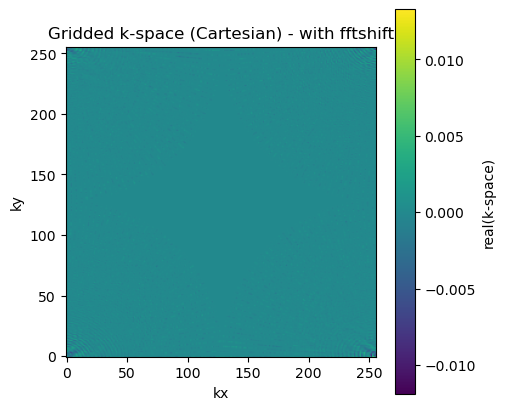

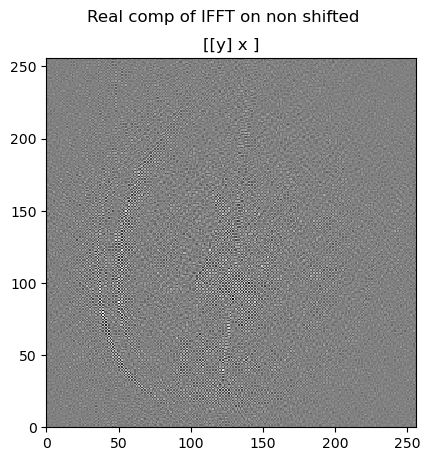

In [8]:
one_coil_zte = zte_radial_kspace[0]
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[...,1]**2)
kspace_cart = sp.gridding(one_coil_zte * dcf, zte_radial_coords, shape=(256, 256))
#kspace_cart = np.fft.ifftshift(kspace_cart)

plt.figure(figsize=(5, 5))
plt.imshow(np.real(kspace_cart), cmap='viridis', origin='lower')
plt.colorbar(label='real(k-space)')
plt.title('Gridded k-space (Cartesian) - with fftshift')
plt.xlabel('kx')
plt.ylabel('ky')
plt.show()

cartesian_image_radial = sp.ifft(kspace_cart)
pl.ImagePlot(np.real(cartesian_image_radial), title='Real comp of IFFT on non shifted')